# V41: LQ45 AI Strategy - No Graph Filter (AI + Markowitz Only)

This notebook modifies **V40** by removing the **Graph/MIS Filter**.

### Hypothesis:
Analysis of previous results (V39 & V40) suggests that the Graph Filter might be excluding high-performing stocks that are highly correlated with the market rally (Market Leaders). By forcing diversification (low correlation), we might be missing out on the primary trend drivers.

### Strategy Logic:
1. **AI Signal**: Same as V39/V40 (Predict MA Trend Direction). Threshold forced to **0.60** to be active.
2. **Risk-Off**: If AI Prob < Threshold -> 100% Cash.
3. **Risk-On (Modified)**: If AI Prob >= Threshold -> **Pass ALL available LQ45 stocks directly to Markowitz Optimization** (No graph filtering step).

### Comparisons:
1. **Proposed AI Strategy (No Graph)**: AI-Gated + Markowitz (Full Universe).
2. **Markowitz Static (Baseline)**.
3. **IHSG Proxy (Benchmark)**.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_price = (1 + market_return).cumprod() * 100

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [2]:
# --- 2. MA Labeling & Feature Engineering ---

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
ma5 = market_price.rolling(window=5).mean()
ma20 = market_price.rolling(window=20).mean()
ma50 = market_price.rolling(window=50).mean()
features['Dist_MA20'] = market_price / ma20
features['Dist_MA50'] = market_price / ma50

# TARGET: MA Slope Direction
target = (ma5.shift(-1) > ma5).astype(int)

features = features.dropna()
target = target.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

xgb_model = xgb.XGBClassifier(n_estimators=120, learning_rate=0.04, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Threshold Logic
train_probs = xgb_model.predict_proba(X_train)[:, 1]
# We force the threshold to 0.60 as per V40 findings/strategy decision
opt_t = 0.60
print(f"[Strategy] Using Fixed Threshold: {opt_t:.2f}")

[Strategy] Using Fixed Threshold: 0.60


In [3]:
# --- 3. Simulation Logic (MODIFIED: No Graph) ---

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    # Add regularization to avoid extreme weights or numerical issues
    sigma += np.eye(len(sigma)) * 1e-4 
    
    try:
        res = minimize(lambda w: -(np.sum(w*mu)/(np.sqrt(np.dot(w.T, np.dot(sigma, w))) + 1e-6)), 
                       [1./len(mu)]*len(mu), method='SLSQP', 
                       bounds=tuple((0, 1) for _ in range(len(mu))), 
                       constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
        return dict(zip(selected_returns.columns, res.x)) if res.success else {}
    except:
        return {} # Fallback if optimization fails

def run_simulation(strategy_type, test_dates, returns, ai_probs=None, threshold=0.5, fee=0.0025):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    static_weights = None
    state_history = []
    
    for i, date in enumerate(test_dates[:-1]):
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-30:loc_idx]
        
        current_state = "Neutral"
        weights = {}

        if strategy_type == 'Proposed AI (No Graph)':
            prob = ai_probs.loc[date]
            is_risk_off = prob < threshold
            
            if is_risk_off: 
                weights = {'CASH': 1.0}
                current_state = "Cash"
            else:
                # MODIFICATION: Skip graph filter, pass ALL window assets to Markowitz
                # We still filter out assets with insufficient data/NaNs in the window if any
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                weights = optimize_markowitz(window_rets[valid_assets])
                current_state = "Invested"
                
        elif strategy_type == 'Markowitz Static':
            if static_weights is None:
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                static_weights = optimize_markowitz(window_rets[valid_assets])
            weights = static_weights
            current_state = "Static"
        
        state_history.append(current_state)
        
        # Transaction Costs
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        val -= (val * turnover * fee)
        
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val); dates.append(next_date); prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history, 'State': state_history + [state_history[-1]]}, index=dates)

Running AI Strategy (No Graph, T=0.60)...
Running Markowitz Static...
Calculating IHSG Benchmark...


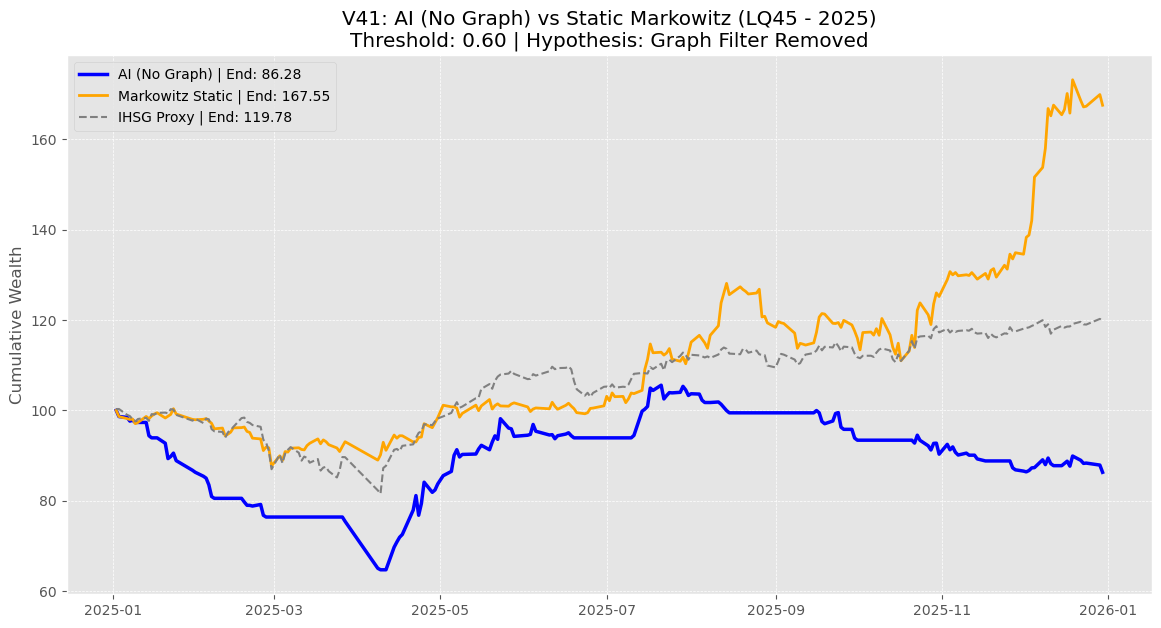


--- Performance Summary ---
AI (No Graph) TC=0.25% : 86.28
Markowitz Static       : 167.55
IHSG Benchmark         : 119.78

AI Activity: Invested 124 days, Cash 112 days


In [4]:
# --- 4. Execution & Visualization ---

test_dates = X_test.index # Correct index from cleaned features
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=test_dates)

print("Running AI Strategy (No Graph, T=0.60)...")
ai_res = run_simulation('Proposed AI (No Graph)', test_dates, returns, ai_probs=test_probs, threshold=opt_t)

print("Running Markowitz Static...")
static_res = run_simulation('Markowitz Static', test_dates, returns)

print("Calculating IHSG Benchmark...")
benchmark_val = 100 * (1 + market_return.loc[test_dates]).cumprod()

# Calculate Stats
ai_final = ai_res['Portfolio_Value'].iloc[-1]
stat_final = static_res['Portfolio_Value'].iloc[-1]
bench_final = benchmark_val.iloc[-1]

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(ai_res.index, ai_res['Portfolio_Value'], label=f'AI (No Graph) | End: {ai_final:.2f}', linewidth=2.5, color='blue')
plt.plot(static_res.index, static_res['Portfolio_Value'], label=f'Markowitz Static | End: {stat_final:.2f}', linewidth=2, color='orange')
plt.plot(benchmark_val.index, benchmark_val, label=f'IHSG Proxy | End: {bench_final:.2f}', linestyle='--', color='gray')

plt.title(f'V41: AI (No Graph) vs Static Markowitz (LQ45 - 2025)\nThreshold: {opt_t:.2f} | Hypothesis: Graph Filter Removed')
plt.ylabel('Cumulative Wealth')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

print("\n--- Performance Summary ---")
print(f"AI (No Graph) TC=0.25% : {ai_final:.2f}")
print(f"Markowitz Static       : {stat_final:.2f}")
print(f"IHSG Benchmark         : {bench_final:.2f}")

# Analyze Activity
days_invested = ai_res[ai_res['State'] == 'Invested'].shape[0]
days_cash = ai_res[ai_res['State'] == 'Cash'].shape[0]
print(f"\nAI Activity: Invested {days_invested} days, Cash {days_cash} days")